# Clase microsimulación espacial

## Librerías

In [226]:
! pip install pyreadr
! pip install ipfn

import geopandas as gpd
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import pyreadr
from ipfn import ipfn

# Ejemplo clase 1 microsimulación

In [227]:
RUTA_CENSO_ZONAL = "../DATA/CENSO24/Cartografía_censo2024_R05/Cartografía_censo2024_R05_Zonal.parquet"

## Entradas

In [228]:
censo_zonal = gpd.read_parquet(RUTA_CENSO_ZONAL)

In [229]:
censo_zonal

,OBJECTID,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,DISTRITO,COD_DISTRITO,...,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,SHAPE
0,1265,5401,5,VALPARAÍSO,54,PETORCA,LA LIGUA,URBANO,LA LIGUA NORTE,1,...,0.0,2.0,987.0,0.0,1.0,0.0,1.0,0.037740,0.000059,"MULTIPOLYGON (((-71.23354 -32.44395, -71.23385..."
1,1266,5401,5,VALPARAÍSO,54,PETORCA,LA LIGUA,URBANO,PLACILLA,5,...,0.0,5.0,635.0,4.0,0.0,0.0,4.0,0.072126,0.000066,"MULTIPOLYGON (((-71.28624 -32.44681, -71.28624..."
2,1267,5401,5,VALPARAÍSO,54,PETORCA,LA LIGUA,URBANO,LA LIGUA SUR,2,...,1.0,0.0,1308.0,3.0,1.0,0.0,1.0,0.058971,0.000076,"MULTIPOLYGON (((-71.24027 -32.4535, -71.24028 ..."
3,1268,5401,5,VALPARAÍSO,54,PETORCA,LA LIGUA,URBANO,LA LIGUA SUR,2,...,1.0,8.0,1095.0,4.0,0.0,0.0,5.0,0.044217,0.000056,"MULTIPOLYGON (((-71.22717 -32.44918, -71.22722..."
4,1269,5401,5,VALPARAÍSO,54,PETORCA,LA LIGUA,URBANO,LA LIGUA SUR,2,...,2.0,4.0,1534.0,0.0,1.0,0.0,2.0,0.034264,0.000065,"MULTIPOLYGON (((-71.23327 -32.45055, -71.23332..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,1955,5405,5,VALPARAÍSO,54,PETORCA,ZAPALLAR,URBANO,CACHAGUA,2,...,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.100125,0.000079,"MULTIPOLYGON (((-71.42234 -32.6264, -71.42229 ..."
690,1956,5302,5,VALPARAÍSO,53,LOS ANDES,CALLE LARGA,URBANO,EL PATAGUAL,2,...,0.0,0.0,337.0,1.0,0.0,0.0,2.0,0.053610,0.000040,"MULTIPOLYGON (((-70.60715 -32.84565, -70.60717..."
691,1957,5405,5,VALPARAÍSO,54,PETORCA,ZAPALLAR,URBANO,CACHAGUA,2,...,1.0,1.0,196.0,1.0,0.0,0.0,0.0,0.134899,0.000177,"MULTIPOLYGON (((-71.42599 -32.62198, -71.42596..."
692,4903,5502,5,VALPARAÍSO,55,QUILLOTA,CALERA,URBANO,EL PEÑÓN,1,...,2.0,0.0,389.0,3.0,1.0,0.0,4.0,0.046758,0.000089,"MULTIPOLYGON (((-71.18963 -32.78971, -71.19069..."


# Ejemplo clase 2 microsimulación

In [230]:
ruta_censo_zonal = "../DATA/CENSO24/parquet/Cartografía_censo2024_R13_Zonal.parquet"
ruta_casen = "../DATA/CASEN24/casen_rm.rds"

In [231]:
censo_zonal = gpd.read_parquet(ruta_censo_zonal)
casen_raw = pyreadr.read_r(ruta_casen)

In [232]:
casen_raw = casen_raw[list(casen_raw.keys())[0]]

In [233]:
casen_raw

,id_vivienda,folio,id_persona,region,area,cod_upm,nse,estrato,hogar,expr,...,men18c,may60c,tipohogar,tot_hog,ind_hacina,indsan,ten_viv,ten_viv_f,allega_ext,allega_int
0,1001701.0,100170101.0,1.0,13.0,1.0,10017.0,2.0,1311112.0,1.0,234.0,...,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
1,1001701.0,100170101.0,2.0,13.0,1.0,10017.0,2.0,1311112.0,1.0,234.0,...,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
2,1001701.0,100170101.0,3.0,13.0,1.0,10017.0,2.0,1311112.0,1.0,234.0,...,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
3,1001701.0,100170101.0,4.0,13.0,1.0,10017.0,2.0,1311112.0,1.0,234.0,...,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
4,1001701.0,100170101.0,5.0,13.0,1.0,10017.0,2.0,1311112.0,1.0,234.0,...,0.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38669,4584903.0,458490301.0,9.0,13.0,1.0,45849.0,3.0,1311513.0,1.0,158.0,...,1.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0
38670,4584907.0,458490701.0,1.0,13.0,1.0,45849.0,3.0,1311513.0,1.0,227.0,...,1.0,0.0,3.0,1.0,1.0,1.0,3.0,2.0,0.0,0.0
38671,4584907.0,458490701.0,2.0,13.0,1.0,45849.0,3.0,1311513.0,1.0,227.0,...,1.0,0.0,3.0,1.0,1.0,1.0,3.0,2.0,0.0,0.0
38672,4584907.0,458490701.0,3.0,13.0,1.0,45849.0,3.0,1311513.0,1.0,227.0,...,1.0,0.0,3.0,1.0,1.0,1.0,3.0,2.0,0.0,0.0


## Pre-procesamiento

Se acota el área del censo únicamente a las zonas censales del Gran Stgo

In [234]:
es_gs = (censo_zonal["PROVINCIA"] == 'SANTIAGO') | (
    censo_zonal["COMUNA"].isin(['SAN BERNARDO', 'PUENTE ALTO', 'PIRQUE', 'PADRE HURTADO'])
)

# SE FILTRA EL DF EN BASE A LA CONDICIÓN
censo_zonal = censo_zonal[es_gs].reset_index(drop=True)

In [235]:
censo_zonal

,OBJECTID,CUT,COD_REGION,REGION,COD_PROVINCIA,PROVINCIA,COMUNA,AREA_C,DISTRITO,COD_DISTRITO,...,n_fuente_elect_otro,n_fuente_elect_no_tiene,n_basura_servicios,n_basura_entierra,n_basura_eriazo,n_basura_rio,n_basura_otro,SHAPE_Length,SHAPE_Area,SHAPE
0,2702,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,0.0,1397.0,1.0,1.0,0.0,0.0,0.055128,0.000085,"MULTIPOLYGON (((-70.67945 -33.34606, -70.67954..."
1,2703,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,0.0,1890.0,2.0,0.0,2.0,2.0,0.098319,0.000228,"MULTIPOLYGON (((-70.66177 -33.35015, -70.66179..."
2,2704,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1.0,1535.0,3.0,2.0,0.0,0.0,0.032909,0.000052,"MULTIPOLYGON (((-70.684 -33.35198, -70.68411 -..."
3,2705,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,0.0,1.0,2167.0,0.0,0.0,0.0,5.0,0.060684,0.000139,"MULTIPOLYGON (((-70.6639 -33.35881, -70.6639 -..."
4,2706,13107,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,HUECHURABA,URBANO,HUECHURABA,1,...,1.0,2.0,1861.0,1.0,1.0,0.0,1.0,0.059381,0.000141,"MULTIPOLYGON (((-70.67542 -33.35296, -70.67568..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1653,4487,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,PEDRO DE VALDIVIA,2,...,0.0,0.0,1434.0,0.0,0.0,1.0,0.0,0.014824,0.000013,"MULTIPOLYGON (((-70.60952 -33.44183, -70.60948..."
1654,4488,13123,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,PROVIDENCIA,URBANO,HOSPITAL MILITAR,8,...,0.0,0.0,814.0,1.0,0.0,0.0,0.0,0.015632,0.000013,"MULTIPOLYGON (((-70.62259 -33.43018, -70.62235..."
1655,4526,13118,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,MACUL,URBANO,CAMINO AGRÍCOLA,4,...,0.0,1.0,1023.0,0.0,0.0,0.0,0.0,0.052187,0.000065,"MULTIPOLYGON (((-70.61641 -33.48493, -70.61661..."
1656,4902,13120,13,METROPOLITANA DE SANTIAGO,131,SANTIAGO,ÑUÑOA,URBANO,ESTADIO NACIONAL,8,...,1.0,1.0,837.0,0.0,0.0,0.0,0.0,0.053861,0.000098,"MULTIPOLYGON (((-70.60672 -33.46546, -70.60664..."


Se extraen las variables de la CASEN que se van a utilizar

In [236]:
# en cierto sentido, las vars_fijas son las que explican a la variable a microsimular


# Variables que no se tocan para microsimular.
# En caso de añadir una nueva el procesamiento posterior cambia

VARS_FIJAS =  ["estrato", "esc", "e6a", "edad", "sexo",
               "v13", "v13_propia", "v13_arrendada", "v13_cedida"]

# Esta es la variable que se modifica:

VARIABLE_A_MICROSIMULAR = "ypchtrabcor"
FUNCION_AGREGACION = np.median

vars_a_cargar = VARS_FIJAS + [VARIABLE_A_MICROSIMULAR]

# Se acota la CASEN únicamente a las variables a utilizar
casen = casen_raw[vars_a_cargar].copy()


# Buena práctica: eliminar el df que ya no se usa, ergo ocupa espacio por las puras
del casen_raw



# Se obtiene la comuna de cada persona
casen["comuna"] = (casen["estrato"]//100).astype("Int64")
casen = casen.drop(columns = "estrato")

comunas_gs = censo_zonal["CUT"].unique()
casen = casen[casen["comuna"].isin(comunas_gs)].reset_index(drop=True)

In [237]:
casen

,esc,e6a,edad,sexo,v13,v13_propia,v13_arrendada,v13_cedida,ypchtrabcor,comuna
0,12.0,11.0,54.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
1,12.0,11.0,28.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
2,17.0,13.0,27.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
3,10.0,11.0,19.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
4,12.0,11.0,56.0,1.0,1.0,2.0,NaN,NaN,520000.0,13111
...,...,...,...,...,...,...,...,...,...,...
32984,8.0,7.0,56.0,2.0,1.0,2.0,NaN,NaN,540787.0,13115
32985,12.0,11.0,33.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115
32986,14.0,12.0,31.0,2.0,3.0,NaN,NaN,8.0,209696.0,13115
32987,NaN,7.0,10.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115


In [238]:
casen.sort_values(by='edad').head(20)

,esc,e6a,edad,sexo,v13,v13_propia,v13_arrendada,v13_cedida,ypchtrabcor,comuna
73,NaN,1.0,0.0,1.0,10.0,NaN,NaN,NaN,465899.0,13107
32919,NaN,1.0,0.0,2.0,2.0,NaN,5.0,NaN,733333.0,13101
1617,NaN,1.0,0.0,2.0,1.0,2.0,NaN,NaN,612500.0,13109
5278,NaN,1.0,0.0,2.0,1.0,2.0,NaN,NaN,1502778.0,13401
22450,NaN,1.0,0.0,2.0,1.0,1.0,NaN,NaN,0.0,13114
32962,NaN,1.0,0.0,1.0,1.0,2.0,NaN,NaN,1450833.0,13110
32556,NaN,1.0,0.0,2.0,2.0,NaN,5.0,NaN,2967567.0,13114
13937,NaN,1.0,0.0,1.0,2.0,NaN,5.0,NaN,146667.0,13119
1402,NaN,1.0,0.0,2.0,1.0,1.0,NaN,NaN,438000.0,13126
22358,NaN,1.0,0.0,2.0,1.0,2.0,NaN,NaN,1059444.0,13201


## Tabla de constraints por zona censal

In [239]:
# Para hacer calzar el censo con la casen

# nos estamos quedando con las cosas que nos interesan del censo, y además estamos renombrando columnas

ZONA_ID = "OBJECTID"


COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5",
    "edad_6_13": "n_edad_6_13",
    "edad_14_17": "n_edad_14_17",
    "edad_18_24": "n_edad_18_24",
    "edad_25_44": "n_edad_25_44",
    "edad_45_59": "n_edad_45_59",
    "edad_60_mas": "n_edad_60_mas",
}

COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]
COLS_TENENCIA = {
    "ten_propia_pagada":"n_tenencia_propia_pagada",
    "ten_propia_pagadandose": "n_tenencia_propia_pagadandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()

for nombre,col in{**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]


# Para educación tendremos 4 niveles
constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = (censo_zonal["n_cine_primaria"] +
                                censo_zonal["n_cine_especial_diferencial"])

constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]

In [240]:
constraints

,OBJECTID,CUT,COMUNA,n_per,n_hog,hombre,mujer,edad_0_5,edad_6_13,edad_14_17,edad_18_24,edad_25_44,edad_45_59,edad_60_mas,educ_nunca,educ_primaria,educ_secundaria,educ_terciaria
0,2702,13107,HUECHURABA,4776.0,1408.0,2294.0,2482.0,209.0,658.0,403.0,541.0,1198.0,1236.0,531.0,227.0,1192.0,955.0,2369.0
1,2703,13107,HUECHURABA,7091.0,1898.0,3386.0,3705.0,314.0,862.0,633.0,1024.0,1449.0,2068.0,741.0,366.0,1672.0,1605.0,3418.0
2,2704,13107,HUECHURABA,4991.0,1604.0,2364.0,2627.0,322.0,598.0,241.0,446.0,1639.0,898.0,847.0,366.0,1443.0,1556.0,1593.0
3,2705,13107,HUECHURABA,6898.0,2178.0,3321.0,3577.0,411.0,892.0,435.0,714.0,2088.0,1687.0,671.0,472.0,1451.0,1303.0,3648.0
4,2706,13107,HUECHURABA,5768.0,1912.0,2748.0,3020.0,348.0,670.0,329.0,604.0,1721.0,1264.0,832.0,417.0,1484.0,1389.0,2459.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1653,4487,13123,PROVIDENCIA,3491.0,1466.0,1539.0,1952.0,150.0,250.0,131.0,357.0,1084.0,653.0,866.0,179.0,500.0,872.0,1937.0
1654,4488,13123,PROVIDENCIA,1553.0,854.0,745.0,808.0,51.0,72.0,33.0,123.0,716.0,256.0,302.0,61.0,155.0,326.0,1010.0
1655,4526,13118,MACUL,3120.0,1088.0,1483.0,1637.0,127.0,293.0,154.0,300.0,846.0,596.0,804.0,161.0,1066.0,1029.0,857.0
1656,4902,13120,ÑUÑOA,2370.0,880.0,1097.0,1273.0,108.0,192.0,71.0,199.0,744.0,409.0,647.0,135.0,772.0,747.0,708.0


# Ejemplo clase 3 microsimulación

In [241]:
ZONA_ID = "OBJECTID"

COLS_SEXO = {"hombre": "n_hombres", "mujer": "n_mujeres"}
COLS_EDAD = {
    "edad_0_5": "n_edad_0_5",
    "edad_6_13": "n_edad_6_13",
    "edad_14_17": "n_edad_14_17",
    "edad_18_24": "n_edad_18_24",
    "edad_25_44": "n_edad_25_44",
    "edad_45_59": "n_edad_45_59",
    "edad_60_mas": "n_edad_60_mas",
}

COLS_EDUC = ["educ_nunca", "educ_primaria", "educ_secundaria", "educ_terciaria"]

COLS_TENENCIA = {
    "ten_propia_pagada": "n_tenencia_propia_pagada",
    "ten_propia_pagandose": "n_tenencia_propia_pagandose",
    "ten_arrendada_contrato": "n_tenencia_arrendada_contrato",
    "ten_arrendada_sin_contrato": "n_tenencia_arrendada_sin_contrato",
    "ten_cedida_trabajo": "n_tenencia_cedida_trabajo",
    "ten_cedida_familiar": "n_tenencia_cedida_familiar",
    "ten_otro": "n_tenencia_otro",
}

constraints = censo_zonal[[ZONA_ID, "CUT", "COMUNA", "n_per", "n_hog"]].copy()

for nombre,col in {**COLS_SEXO, **COLS_EDAD}.items():
    constraints[nombre] = censo_zonal[col]

# Para educación tendremos 4 niveles
constraints["educ_nunca"] = censo_zonal["n_cine_nunca_curso_primera_infancia"]
constraints["educ_primaria"] = (censo_zonal["n_cine_primaria"] + 
                               censo_zonal["n_cine_especial_diferencial"])
constraints["educ_secundaria"] = censo_zonal["n_cine_secundaria"]
constraints["educ_terciaria"] = censo_zonal["n_cine_terciaria_maestria_doctorado"]

In [242]:
# Se calculan personas por hogar
personas_por_hogar = np.where(
    censo_zonal["n_hog"] > 0, censo_zonal["n_per"] / censo_zonal["n_hog"], 0
)
for nombre, col in COLS_TENENCIA.items():
    constraints[nombre] = censo_zonal[col] * personas_por_hogar

# Se ordenan las categorías
CATEGORIAS = {
    "sexo_cat": list(COLS_SEXO.keys()),
    "edad_cat": list(COLS_EDAD.keys()),
    "educ_cat": COLS_EDUC,
    "tenencia_cat": list(COLS_TENENCIA.keys()),
}

constraints = constraints.set_index(ZONA_ID)

In [243]:
constraints

,CUT,COMUNA,n_per,n_hog,hombre,mujer,edad_0_5,edad_6_13,edad_14_17,edad_18_24,...,educ_primaria,educ_secundaria,educ_terciaria,ten_propia_pagada,ten_propia_pagandose,ten_arrendada_contrato,ten_arrendada_sin_contrato,ten_cedida_trabajo,ten_cedida_familiar,ten_otro
OBJECTID,,,,,,,,,,,,,,,,,,,,,
2702,13107,HUECHURABA,4776.0,1408.0,2294.0,2482.0,209.0,658.0,403.0,541.0,...,1192.0,955.0,2369.0,803.914773,2954.471591,844.619318,64.448864,6.784091,78.017045,23.744318
2703,13107,HUECHURABA,7091.0,1898.0,3386.0,3705.0,314.0,862.0,633.0,1024.0,...,1672.0,1605.0,3418.0,1584.080084,4584.118546,735.999473,52.304531,14.944152,70.984721,44.832455
2704,13107,HUECHURABA,4991.0,1604.0,2364.0,2627.0,322.0,598.0,241.0,446.0,...,1443.0,1556.0,1593.0,1954.082294,1689.596633,849.465711,239.592893,15.557980,174.249377,65.343516
2705,13107,HUECHURABA,6898.0,2178.0,3321.0,3577.0,411.0,892.0,435.0,714.0,...,1451.0,1303.0,3648.0,1079.989899,4278.786961,1361.864096,53.841139,19.002755,88.679522,15.835629
2706,13107,HUECHURABA,5768.0,1912.0,2748.0,3020.0,348.0,670.0,329.0,604.0,...,1484.0,1389.0,2459.0,1357.531381,2371.154812,1478.200837,229.271967,27.150628,238.322176,60.334728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4487,13123,PROVIDENCIA,3491.0,1466.0,1539.0,1952.0,150.0,250.0,131.0,357.0,...,500.0,872.0,1937.0,1176.366985,473.880628,1393.066166,109.540246,88.108458,209.555252,40.482265
4488,13123,PROVIDENCIA,1553.0,854.0,745.0,808.0,51.0,72.0,33.0,123.0,...,155.0,326.0,1010.0,334.604215,214.583138,829.236534,76.377049,21.822014,63.647541,12.729508
4526,13118,MACUL,3120.0,1088.0,1483.0,1637.0,127.0,293.0,154.0,300.0,...,1066.0,1029.0,857.0,1502.647059,324.044118,688.235294,255.220588,17.205882,281.029412,51.617647


In [244]:
casen

,esc,e6a,edad,sexo,v13,v13_propia,v13_arrendada,v13_cedida,ypchtrabcor,comuna
0,12.0,11.0,54.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
1,12.0,11.0,28.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
2,17.0,13.0,27.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
3,10.0,11.0,19.0,2.0,1.0,2.0,NaN,NaN,520000.0,13111
4,12.0,11.0,56.0,1.0,1.0,2.0,NaN,NaN,520000.0,13111
...,...,...,...,...,...,...,...,...,...,...
32984,8.0,7.0,56.0,2.0,1.0,2.0,NaN,NaN,540787.0,13115
32985,12.0,11.0,33.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115
32986,14.0,12.0,31.0,2.0,3.0,NaN,NaN,8.0,209696.0,13115
32987,NaN,7.0,10.0,1.0,3.0,NaN,NaN,8.0,209696.0,13115


# Ejemplo clase 4 microsimulación

In [245]:
# Imputación de esc en base a e6a

falta_esc = casen["esc"].isna()
print(f"Faltan {falta_esc.sum()} de {len(casen)} registros")

# Regresión Lineal para imputar esc
modelo_esc = LinearRegression().fit(
     casen.loc[~falta_esc, ["e6a"]], casen.loc[~falta_esc, "esc"]
)

# Se predice la escolaridad únicamente para los registros sin esc
pred = modelo_esc.predict(casen.loc[falta_esc, ["e6a"]])
casen.loc[falta_esc, "esc"] = np.clip(np.round(pred), 0, 20)

Faltan 5949 de 32989 registros


In [246]:
SEED = 123

In [247]:
# Recodificación de categorías del censo

## Sexo
casen["sexo_cat"] = casen["sexo"].map({1: "hombre", 2: "mujer"})

## Edad
casen["edad_cat"] = pd.cut(
    casen["edad"],
    bins=[0, 6, 14, 18, 25, 45, 60, np.inf],
    labels=list(COLS_EDAD.keys()),
    right=False,
    include_lowest=True,
).astype(str)

## Educación
casen["educ_cat"] = pd.cut(
    casen["esc"],
    bins=[-1, 0, 8, 12, np.inf],
    labels=COLS_EDUC,
).astype(str)

## Tenencia de vivienda
condiciones = [
    (casen["v13"] == 1) & (casen["v13_propia"] == 1),
    (casen["v13"] == 1) & (casen["v13_propia"] == 2),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 5),
    (casen["v13"] == 2) & (casen["v13_arrendada"] == 6),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 7),
    (casen["v13"] == 3) & (casen["v13_cedida"] == 8),
]
categorias_tenencia = [
    "ten_propia_pagada",
    "ten_propia_pagandose",
    "ten_arrendada_contrato",
    "ten_arrendada_sin_contrato",
    "ten_cedida_trabajo",
    "ten_cedida_familiar",
]
casen["tenencia_cat"] = np.select(condiciones, categorias_tenencia, default="ten_otro")

casen["ID"] = np.arange(len(casen))

# sin la variable a microsimular, la persona no puede ser "donante"
sin_valor = casen[VARIABLE_A_MICROSIMULAR].isna()
print(f"Personas excluidas del pool de donantes por {VARIABLE_A_MICROSIMULAR} faltante: {sin_valor.sum()}")
casen = casen[~sin_valor].reset_index(drop=True)

casen[["comuna", "sexo_cat", "edad_cat", "educ_cat", "tenencia_cat", VARIABLE_A_MICROSIMULAR, "ID"]]



Personas excluidas del pool de donantes por ypchtrabcor faltante: 0


,comuna,sexo_cat,edad_cat,educ_cat,tenencia_cat,ypchtrabcor,ID
0,13111,mujer,edad_45_59,educ_secundaria,ten_propia_pagandose,520000.0,0
1,13111,mujer,edad_25_44,educ_secundaria,ten_propia_pagandose,520000.0,1
2,13111,mujer,edad_25_44,educ_terciaria,ten_propia_pagandose,520000.0,2
3,13111,mujer,edad_18_24,educ_secundaria,ten_propia_pagandose,520000.0,3
4,13111,hombre,edad_45_59,educ_secundaria,ten_propia_pagandose,520000.0,4
...,...,...,...,...,...,...,...
32984,13115,mujer,edad_45_59,educ_primaria,ten_propia_pagandose,540787.0,32984
32985,13115,hombre,edad_25_44,educ_secundaria,ten_cedida_familiar,209696.0,32985
32986,13115,mujer,edad_25_44,educ_terciaria,ten_cedida_familiar,209696.0,32986
32987,13115,hombre,edad_6_13,educ_primaria,ten_cedida_familiar,209696.0,32987


## Algoritmo de microsimulación

In [248]:
def pesos_por_persona(seed, codigos, celda_a_personas):
    """Ejecuta ipfn sobre la tabla seed (conteo de la muestra CASEN de la
    comuna, en forma de arreglo N-dimensional) contra los objetivos codigos
    (uno por variable-constraint), y devuelve el peso fraccionario que le
    corresponde a CADA PERSONA de la muestra (no a cada celda).
    """
    # ipfn necesita saber qué eje del arreglo seed corresponde a cada variable.
    # Como seed tiene un eje por variable (sexo, edad, educación, tenencia) en
    # ese mismo orden, dims = [[0], [1], [2], [3]]: "el objetivo 0 (sexo) se
    # aplica sobre el eje 0, el objetivo 1 (edad) sobre el eje 1", etc.
    dims = [[i] for i in range(len(codigos["objetivos"]))]

    # Acá es donde ipfn hace TODO el trabajo de reponderar (raking/IPF):
    # ajusta iterativamente la tabla seed hasta que sus marginales calcen
    # con codigos["objetivos"]. .copy() porque ipfn modifica la tabla que
    # recibe, y queremos poder reusar seed para la próxima zona.
    IPF = ipfn.ipfn(
        seed.copy(),
        codigos["objetivos"],
        dims,
        convergence_rate=1e-6,   # qué tan exacto debe quedar el ajuste
        max_iteration=50,        # tope de vueltas si no converge antes
    )
    tabla_reponderada = IPF.iteration()  # arreglo del mismo tamaño que seed,
                                          # pero con los valores ya ajustados

    # codigos["indices"] es una tupla con la "coordenada" de cada persona en
    # la tabla (su combinación exacta de sexo/edad/educación/tenencia). Al usarla
    # para indexar tabla_reponderada, cada persona recibe el peso ajustado de
    # SU celda (varias personas comparten la misma celda si tienen las mismas
    # 4 categorías, y por ahora reciben el mismo número: el peso de la celda).
    peso_celda = tabla_reponderada[codigos["indices"]]

    # Si 3 personas comparten una celda que quedó con peso ajustado 9, cada una
    # debería valer 9/3 = 3 personas, no 9 cada una. Por eso dividimos por
    # cuántas personas hay en esa celda originalmente (celda_a_personas).
    return peso_celda / celda_a_personas


def integerise_trs(pesos, rng):
    """Truncate-Replicate-Sample: pasa de pesos fraccionarios a una población
    entera reproducible. Devuelve un array de índices (posiciones en pesos),
    uno por cada persona sintética generada.
    """
    # Paso 1 (Truncate): separamos cada peso en su parte entera y su resto.
    # Ej. un peso de 2.37 -> parte_entera=2 (esas 2 copias van seguro),
    # parte_fraccionaria=0.37 (0.37 de probabilidad de una 3ª copia).
    parte_entera = np.floor(pesos).astype(int)
    parte_fraccionaria = pesos - parte_entera

    # Paso 2 (Replicate): armamos la lista de copias "seguras". np.repeat(idx, n)
    # repite el índice 0 tantas veces como diga parte_entera[0], el índice 1
    # tantas veces como diga parte_entera[1], etc. Si nadie tiene parte entera
    # (todos los pesos son < 1), esto queda vacío.
    idx = np.arange(len(pesos))
    replicados = np.repeat(idx, parte_entera)

    # ¿Cuántas personas le faltan a esta zona para llegar a su población total?
    # (el total objetivo es la suma de todos los pesos, redondeada)
    n_total = int(round(pesos.sum()))
    n_faltante = n_total - parte_entera.sum()

    # Paso 3 (Sample): completamos lo que falta sorteando personas, dándole más
    # chance de ser sorteada a quien tenga una parte fraccionaria más alta (una
    # persona con 0.9 tiene mucha más chance de la copia extra que una con 0.1).
    if n_faltante > 0 and parte_fraccionaria.sum() > 0:
        probs = parte_fraccionaria / parte_fraccionaria.sum()
        extra = rng.choice(idx, size=n_faltante, replace=True, p=probs)
        replicados = np.concatenate([replicados, extra])

    return replicados

In [249]:
import contextlib
import io
import warnings

rng = np.random.default_rng(SEED)

VARS_CONSTRAINT = list(CATEGORIAS.keys())  # ["sexo_cat", "edad_cat", "educ_cat", "tenencia_cat"]

resultados_zona = []
zonas_sin_donantes = []

buffer_salida = io.StringIO()
with contextlib.redirect_stdout(buffer_salida), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)

    for comuna_cut, cons_comuna in constraints.groupby("CUT"):
        muestra_comuna = casen[casen["comuna"] == comuna_cut]

        if len(muestra_comuna) == 0:
            zonas_sin_donantes.extend(cons_comuna.index.tolist())
            continue

        # tabla de conteo de la muestra (una vez por comuna): igual que en la sección 6
        indices = {
            var: pd.Categorical(muestra_comuna[var], categories=CATEGORIAS[var]).codes
            for var in VARS_CONSTRAINT
        }
        forma = tuple(len(CATEGORIAS[var]) for var in VARS_CONSTRAINT)
        seed_tabla = np.zeros(forma)
        indices_tupla = tuple(indices[var] for var in VARS_CONSTRAINT)
        np.add.at(seed_tabla, indices_tupla, 1)
        celda_a_personas = seed_tabla[indices_tupla]  # cuántas personas comparten la celda de cada persona

        valores_objetivo = muestra_comuna[VARIABLE_A_MICROSIMULAR].to_numpy()

        for zona_id, fila in cons_comuna.iterrows():
            if fila["n_per"] == 0:
                continue

            objetivos = [
                np.array([fila[cat] for cat in CATEGORIAS[var]], dtype=float)
                for var in VARS_CONSTRAINT
            ]

            pesos = pesos_por_persona(
                seed_tabla, {"objetivos": objetivos, "indices": indices_tupla}, celda_a_personas
            )
            sinteticos_idx = integerise_trs(pesos, rng)

            valores_sinteticos = valores_objetivo[sinteticos_idx]

            resultados_zona.append({
                "zona_id": zona_id,
                "CUT": comuna_cut,
                "n_sintetico": len(sinteticos_idx),
                "n_censo": fila["n_per"],
                "valor_zona": FUNCION_AGREGACION(valores_sinteticos) if len(valores_sinteticos) else np.nan,
            })

resultados_zona = pd.DataFrame(resultados_zona).set_index("zona_id")
print(f"Zonas simuladas: {len(resultados_zona)}")
print(f"Zonas sin comuna con donantes CASEN: {len(zonas_sin_donantes)}")
resultados_zona.head()

Zonas simuladas: 1656
Zonas sin comuna con donantes CASEN: 0


,CUT,n_sintetico,n_censo,valor_zona
zona_id,,,,
4309,13101,3918,3923.0,294583.0
4310,13101,6245,6250.0,324583.0
4311,13101,4038,4038.0,347500.0
4312,13101,3050,3050.0,317778.0
4313,13101,5597,5599.0,421667.0


Lo anterior sirve para corroborar la calidad de la microsimulación considerando que la población simulada se asemeja bastante a la censada.

El valor zona en este ejemplo corresponde al ingreso promedio por zona, lo que al dividirse por el número de personas censadas da el pércapita.

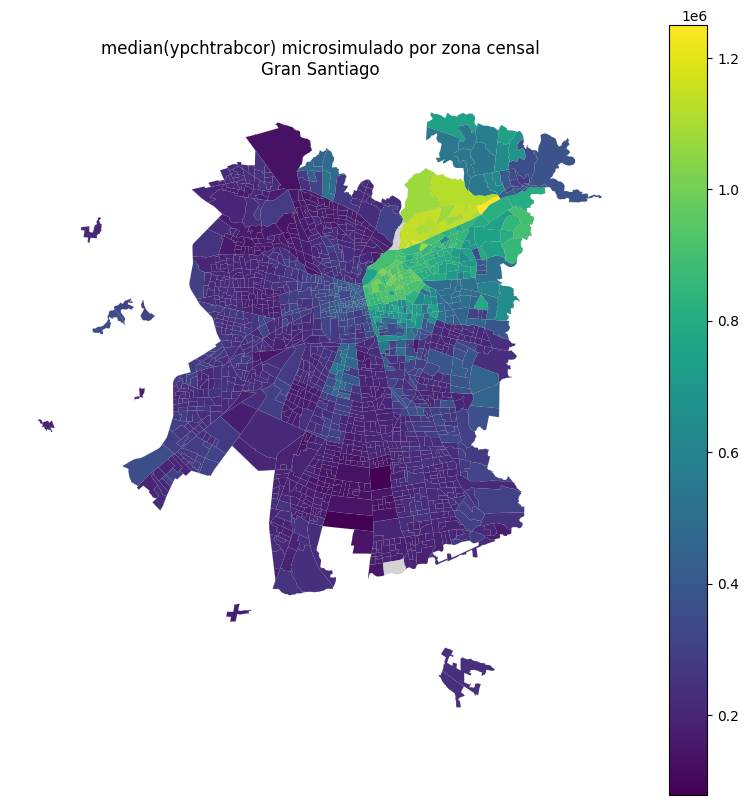

In [250]:
zonas_mapa = censo_zonal.set_index(ZONA_ID).join(resultados_zona[["valor_zona"]])

fig, ax = plt.subplots(figsize=(10, 10))
zonas_mapa.plot(
    column="valor_zona",
    cmap="viridis",
    linewidth=0.05,
    edgecolor="grey",
    legend=True,
    missing_kwds={"color": "lightgrey", "label": "sin dato"},
    ax=ax,
)
ax.set_title(f"{FUNCION_AGREGACION.__name__}({VARIABLE_A_MICROSIMULAR}) microsimulado por zona censal\nGran Santiago")
ax.set_axis_off()
plt.show()